In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from sklearn.metrics import f1_score

def summarize_cv_results(root_dir, thresh=5.0, save_csv=False, head=20):
    """
    Summarize CV test metrics for a given run directory.

    Args:
        root_dir (str | Path): Root folder containing fold subdirs with *_predicted_true_values.csv files.
        thresh (float): PDFF threshold used for binarization (default 5.0).
        save_csv (bool): If True, saves CSV outputs next to root_dir.
        head (int): How many top rows of the micro-sorted table to show.

    Returns:
        dict: {
          'test_folds_df': per-fold rows,
          'macro': macro mean±std across folds,
          'micro': micro metrics aggregated across folds,
          'micro_sorted': micro sorted by (FN+FP)
        }
    """
    # =========================
    # 🔧 Config
    # =========================
    root_dir = Path(root_dir)
    THRESH = float(thresh)

    def binarize(x: float) -> int:
        return int(x > THRESH)

    # =========================
    # 🔍 Collect files (test only)
    # =========================
    csv_files = list(root_dir.rglob("*_predicted_true_values.csv"))

    records = []  # per-fold rows
    for csv_path in csv_files:
        fname = csv_path.name.lower()
        if not fname.startswith("test"):   # only test CSVs
            continue

        try:
            df = pd.read_csv(csv_path)

            # ---- parse fold / agg / run / backbone from path ----
            parts = list(csv_path.parts)
            fold_idx = None
            agg = "unknown"
            run_name = "unknown"
            backbone = "unknown"

            for i, p in enumerate(parts):
                m = re.fullmatch(r"fold(\d+)", p)
                if m:
                    fold_idx = int(m.group(1))
                    agg = parts[i-1] if i-1 >= 0 else agg            # e.g., max / attention / mean
                    run_name = parts[i-2] if i-2 >= 0 else run_name  # e.g., swe_700frame_window2100_skip3_100ep
                    backbone = parts[i-3] if i-3 >= 0 else backbone  # e.g., swin_tiny_patch4...
                    break

            # ---- metrics ----
            dd = df[["target", "prediction"]].dropna().copy()
            if len(dd) == 0:
                raise ValueError("Empty dataframe after dropna().")

            y_true = dd["target"].apply(binarize).astype(int).values
            y_pred = dd["prediction"].apply(binarize).astype(int).values

            tp = int(((y_true == 1) & (y_pred == 1)).sum())
            tn = int(((y_true == 0) & (y_pred == 0)).sum())
            fp = int(((y_true == 0) & (y_pred == 1)).sum())
            fn = int(((y_true == 1) & (y_pred == 0)).sum())
            n  = int(len(dd))

            ae = np.abs(dd["target"] - dd["prediction"])
            se = (dd["target"] - dd["prediction"]) ** 2
            mae  = float(ae.mean())
            rmse = float(np.sqrt(se.mean()))
            try:
                pearson_r = float(np.corrcoef(dd["target"], dd["prediction"])[0, 1])
            except Exception:
                pearson_r = np.nan

            recall      = tp / (tp + fn) if (tp + fn) > 0 else np.nan    # sensitivity/TPR
            specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
            precision   = tp / (tp + fp) if (tp + fp) > 0 else np.nan
            accuracy    = (tp + tn) / n if n > 0 else np.nan
            f1          = f1_score(y_true, y_pred) if (tp+fp > 0 and tp+fn > 0) else np.nan
            fnr         = fn / (tp + fn) if (tp + fn) > 0 else np.nan
            fpr         = fp / (fp + tn) if (fp + tn) > 0 else np.nan
            bal_acc     = np.nanmean([recall, specificity])

            records.append({
                "backbone": backbone,
                "run": run_name,
                "agg": agg,
                "model_key": f"{backbone}/{run_name}/{agg}",
                "fold": fold_idx,
                "N": n,
                "TP": tp, "TN": tn, "FP": fp, "FN": fn,
                "mae": mae, "rmse": rmse, "pearson_r": pearson_r,
                "recall": recall, "specificity": specificity,
                "precision": precision, "accuracy": accuracy,
                "f1": f1, "fnr": fnr, "fpr": fpr, "balanced_acc": bal_acc,
                "abs_err_sum": float(ae.sum()),
                "sq_err_sum": float(se.sum())
            })

        except Exception as e:
            print(f"[ERROR] Failed to process {csv_path}: {e}")

    test_folds_df = pd.DataFrame(records)

    # Early exit: no files
    if test_folds_df.empty:
        print("No test CSVs found under:", root_dir)
        return {"test_folds_df": test_folds_df,
                "macro": pd.DataFrame(),
                "micro": pd.DataFrame(),
                "micro_sorted": pd.DataFrame()}

    # =========================
    # 🧮 Macro (mean±std across folds)
    # =========================
    metrics = ["mae","rmse","pearson_r","recall","specificity","precision",
               "accuracy","f1","fnr","fpr","balanced_acc"]

    macro = (
        test_folds_df
        .groupby(["backbone","run","agg","model_key"], as_index=False)
        .agg({**{m:["mean","std"] for m in metrics}, **{"N":"sum"}})
    )
    # flatten columns
    macro.columns = ["backbone","run","agg","model_key"] + [f"{a}_{b}" for a,b in macro.columns[4:]]
    macro = macro.sort_values(["model_key"]).reset_index(drop=True)

    # =========================
    # 🧮 Micro (sum over folds)
    # =========================
    agg_counts = (
        test_folds_df
        .groupby(["backbone","run","agg","model_key"], as_index=False)
        .agg({"TP":"sum","TN":"sum","FP":"sum","FN":"sum","N":"sum",
              "abs_err_sum":"sum","sq_err_sum":"sum"})
    )

    def compute_micro(row):
        TP, TN, FP, FN, N = row["TP"], row["TN"], row["FP"], row["FN"], row["N"]
        mae  = row["abs_err_sum"]/N if N>0 else np.nan
        rmse = np.sqrt(row["sq_err_sum"]/N) if N>0 else np.nan
        recall      = TP/(TP+FN) if (TP+FN)>0 else np.nan
        specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
        precision   = TP/(TP+FP) if (TP+FP)>0 else np.nan
        accuracy    = (TP+TN)/N if N>0 else np.nan
        f1          = (2*TP)/(2*TP+FP+FN) if (2*TP+FP+FN)>0 else np.nan
        fnr         = FN/(TP+FN) if (TP+FN)>0 else np.nan
        fpr         = FP/(FP+TN) if (FP+TN)>0 else np.nan
        bal_acc     = np.nanmean([recall, specificity])
        return pd.Series({
            "mae": mae, "rmse": rmse, "recall": recall, "specificity": specificity,
            "precision": precision, "accuracy": accuracy, "f1": f1,
            "fnr": fnr, "fpr": fpr, "balanced_acc": bal_acc
        })

    micro_metrics = agg_counts.apply(compute_micro, axis=1)
    micro = pd.concat([agg_counts, micro_metrics], axis=1).reset_index(drop=True)

    # =========================
    # 🧾 Sort: (FN+FP) ascending
    # =========================
    micro_sorted = (
        micro.assign(err_count=lambda d: d["FN"]+d["FP"])
             .sort_values(["err_count","model_key"])
             .reset_index(drop=True)
    )

    # =========================
    # 💾 Save (optional)
    # =========================
    if save_csv:
        out_dir = root_dir
        (out_dir / "cv_test_all_folds.csv").write_text(
            test_folds_df.to_csv(index=False)
        )
        (out_dir / "cv_test_macro.csv").write_text(
            macro.to_csv(index=False)
        )
        (out_dir / "cv_test_micro.csv").write_text(
            micro.to_csv(index=False)
        )
        (out_dir / "cv_test_micro_sorted.csv").write_text(
            micro_sorted.to_csv(index=False)
        )

    # 👀 Show top rows
    try:
        from IPython.display import display  # in notebooks
        display(micro_sorted.head(head))
    except Exception:
        print(micro_sorted.head(head))

    return {
        "test_folds_df": test_folds_df,
        "macro": macro,
        "micro": micro,
        "micro_sorted": micro_sorted
    }


In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from sklearn.metrics import f1_score

def summarize_cv_results(root_dir, thresh=5.0, save_csv=False, head=20):
    """
    Summarize CV (val & test) metrics for a given run directory.

    - Reads both *val*_predicted_true_values.csv and *test*_predicted_true_values.csv
    - Computes per-fold metrics, macro (mean±std across folds), and micro (aggregate across folds)
    - Returns a combined-sorted micro table where ALL vals are on top, followed by ALL tests,
      and tests follow the SAME model order determined by vals. Model keys that exist
      only in test are appended at the end (alphabetically).

    Args:
        root_dir (str | Path): Root folder containing fold subdirs with *_predicted_true_values.csv files.
        thresh (float): PDFF threshold used for binarization (default 5.0).
        save_csv (bool): If True, saves CSV outputs in root_dir.
        head (int): How many top rows of the combined-sorted table to display.

    Returns:
        dict with:
          'fold_rows'      : per-fold rows (with 'set' column in {'val','test'})
          'macro'          : mean±std across folds per (set, model)
          'micro'          : micro metrics aggregated across folds per (set, model)
          'combined_sorted': micro sorted as: ALL vals first (base order), then ALL tests in same order
    """
    root_dir = Path(root_dir)
    THRESH = float(thresh)

    def binarize(x: float) -> int:
        return int(x > THRESH)

    # ---------------------------------
    # Collect files (val & test)
    # ---------------------------------
    csv_files = list(root_dir.rglob("*_predicted_true_values.csv"))
    records = []

    for csv_path in csv_files:
        fname = csv_path.name.lower()
        if   fname.startswith("val"):  set_name = "val"
        elif fname.startswith("test"): set_name = "test"
        else:                          set_name = "unknown"

        try:
            df = pd.read_csv(csv_path)

            # ---- parse fold / agg / run / backbone from path ----
            parts = list(csv_path.parts)
            fold_idx = None
            agg = "unknown"
            run_name = "unknown"
            backbone = "unknown"

            for i, p in enumerate(parts):
                m = re.fullmatch(r"fold(\d+)", p)
                if m:
                    fold_idx = int(m.group(1))
                    agg = parts[i-1] if i-1 >= 0 else agg
                    run_name = parts[i-2] if i-2 >= 0 else run_name
                    backbone = parts[i-3] if i-3 >= 0 else backbone
                    break

            # ---- metrics ----
            dd = df[["target", "prediction"]].dropna().copy()
            if len(dd) == 0:
                raise ValueError("Empty dataframe after dropna().")

            y_true = dd["target"].apply(binarize).astype(int).values
            y_pred = dd["prediction"].apply(binarize).astype(int).values

            tp = int(((y_true == 1) & (y_pred == 1)).sum())
            tn = int(((y_true == 0) & (y_pred == 0)).sum())
            fp = int(((y_true == 0) & (y_pred == 1)).sum())
            fn = int(((y_true == 1) & (y_pred == 0)).sum())
            n  = int(len(dd))

            ae = np.abs(dd["target"] - dd["prediction"])
            se = (dd["target"] - dd["prediction"]) ** 2
            mae  = float(ae.mean())
            rmse = float(np.sqrt(se.mean()))
            try:
                pearson_r = float(np.corrcoef(dd["target"], dd["prediction"])[0, 1])
            except Exception:
                pearson_r = np.nan

            recall      = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
            precision   = tp / (tp + fp) if (tp + fp) > 0 else np.nan
            accuracy    = (tp + tn) / n if n > 0 else np.nan
            f1          = f1_score(y_true, y_pred) if (tp+fp > 0 and tp+fn > 0) else np.nan
            fnr         = fn / (tp + fn) if (tp + fn) > 0 else np.nan
            fpr         = fp / (fp + tn) if (fp + tn) > 0 else np.nan
            bal_acc     = np.nanmean([recall, specificity])

            records.append({
                "set": set_name,
                "backbone": backbone,
                "run": run_name,
                "agg": agg,
                "model_key": f"{backbone}/{run_name}/{agg}",
                "fold": fold_idx,
                "N": n,
                "TP": tp, "TN": tn, "FP": fp, "FN": fn,
                "mae": mae, "rmse": rmse, "pearson_r": pearson_r,
                "recall": recall, "specificity": specificity,
                "precision": precision, "accuracy": accuracy,
                "f1": f1, "fnr": fnr, "fpr": fpr, "balanced_acc": bal_acc,
                "abs_err_sum": float(ae.sum()),
                "sq_err_sum": float(se.sum())
            })

        except Exception as e:
            print(f"[ERROR] Failed to process {csv_path}: {e}")

    fold_rows = pd.DataFrame(records)
    fold_rows = fold_rows[fold_rows["set"].isin(["val","test"])].reset_index(drop=True)

    if fold_rows.empty:
        print("No val/test CSVs found under:", root_dir)
        return {"fold_rows": fold_rows,
                "macro": pd.DataFrame(),
                "micro": pd.DataFrame(),
                "combined_sorted": pd.DataFrame()}

    # ---------------------------------
    # Macro (mean±std across folds), per set
    # ---------------------------------
    metrics = ["mae","rmse","pearson_r","recall","specificity","precision",
               "accuracy","f1","fnr","fpr","balanced_acc"]

    macro = (
        fold_rows
        .groupby(["set","backbone","run","agg","model_key"], as_index=False)
        .agg({**{m:["mean","std"] for m in metrics}, **{"N":"sum"}})
    )
    macro.columns = ["set","backbone","run","agg","model_key"] + [f"{a}_{b}" for a,b in macro.columns[5:]]
    macro = macro.sort_values(["model_key","set"]).reset_index(drop=True)

    # ---------------------------------
    # Micro (sum over folds), per set
    # ---------------------------------
    agg_counts = (
        fold_rows
        .groupby(["set","backbone","run","agg","model_key"], as_index=False)
        .agg({"TP":"sum","TN":"sum","FP":"sum","FN":"sum","N":"sum",
              "abs_err_sum":"sum","sq_err_sum":"sum"})
    )

    def compute_micro(row):
        TP, TN, FP, FN, N = row["TP"], row["TN"], row["FP"], row["FN"], row["N"]
        mae  = row["abs_err_sum"]/N if N>0 else np.nan
        rmse = np.sqrt(row["sq_err_sum"]/N) if N>0 else np.nan
        recall      = TP/(TP+FN) if (TP+FN)>0 else np.nan
        specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
        precision   = TP/(TP+FP) if (TP+FP)>0 else np.nan
        accuracy    = (TP+TN)/N if N>0 else np.nan
        f1          = (2*TP)/(2*TP+FP+FN) if (2*TP+FP+FN)>0 else np.nan
        fnr         = FN/(TP+FN) if (TP+FN)>0 else np.nan
        fpr         = FP/(FP+TN) if (FP+TN)>0 else np.nan
        bal_acc     = np.nanmean([recall, specificity])
        return pd.Series({
            "mae": mae, "rmse": rmse, "recall": recall, "specificity": specificity,
            "precision": precision, "accuracy": accuracy, "f1": f1,
            "fnr": fnr, "fpr": fpr, "balanced_acc": bal_acc
        })

    micro_metrics = agg_counts.apply(compute_micro, axis=1)
    micro = pd.concat([agg_counts, micro_metrics], axis=1).reset_index(drop=True)

    # ---------------------------------
    # Global ordering:
    #  - build base model order from VAL rows (alphabetical by model_key)
    #  - append model_keys that exist only in TEST (alphabetical)
    #  - final table = all VAL rows in base order, then all TEST rows in the same order
    # ---------------------------------
    val_rows_only = micro[micro["set"] == "val"].copy()
    base_order = (
        val_rows_only.sort_values(["model_key"])["model_key"].tolist()
    )
    # add keys that exist only in test
    all_keys = micro["model_key"].unique().tolist()
    missing = [k for k in all_keys if k not in base_order]
    base_order += sorted(missing)

    def _order_block(df_block, keys):
        out = (
            df_block.set_index("model_key")
                    .reindex(keys)
                    .reset_index()
        )
        return out[out["set"].notna()]

    val_sorted  = _order_block(micro[micro["set"] == "val"],  base_order)
    test_sorted = _order_block(micro[micro["set"] == "test"], base_order)

    combined_sorted = pd.concat([val_sorted, test_sorted], ignore_index=True)

    # ---------------------------------
    # Save (optional)
    # ---------------------------------
    if save_csv:
        out_dir = root_dir
        (out_dir / "cv_fold_rows.csv").write_text(fold_rows.to_csv(index=False))
        (out_dir / "cv_macro_by_set.csv").write_text(macro.to_csv(index=False))
        (out_dir / "cv_micro_by_set.csv").write_text(micro.to_csv(index=False))
        (out_dir / "cv_combined_sorted.csv").write_text(combined_sorted.to_csv(index=False))

    # Show head
    try:
        from IPython.display import display
        display(combined_sorted.head(head))
    except Exception:
        print(combined_sorted.head(head))

    return {
        "fold_rows": fold_rows,
        "macro": macro,
        "micro": micro,
        "combined_sorted": combined_sorted
    }


In [3]:
# 2) Another run folder + save CSVs
res = summarize_cv_results(
    "/research/projects/Sahika/projects/liver_PDFF/clean_code/runs/swin_tiny_patch4_window7_224.ms_in1k_gelu_CV/swe_600frame_window3000_skip5_100ep",
    thresh=5.0,
    save_csv=False
)

# Access results:
#res["micro_sorted"].head(10)

,model_key,set,backbone,run,agg,TP,TN,FP,FN,N,...,mae,rmse,recall,specificity,precision,accuracy,f1,fnr,fpr,balanced_acc
0,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV/s...,val,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV,swe_600frame_window3000_skip5_100ep,attention,39,46,4,21,110,...,3.960000,6.458411,0.650000,0.920000,0.906977,0.772727,0.757282,0.350000,0.080000,0.785000
1,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV/s...,val,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV,swe_600frame_window3000_skip5_100ep,gated,53,16,34,7,110,...,4.978936,7.516086,0.883333,0.320000,0.609195,0.627273,0.721088,0.116667,0.680000,0.601667
2,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV/s...,val,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV,swe_600frame_window3000_skip5_100ep,max,49,40,10,11,110,...,3.891286,6.218437,0.816667,0.800000,0.830508,0.809091,0.823529,0.183333,0.200000,0.808333
3,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV/s...,val,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV,swe_600frame_window3000_skip5_100ep,mean,44,26,24,16,110,...,4.905264,7.163699,0.733333,0.520000,0.647059,0.636364,0.687500,0.266667,0.480000,0.626667
4,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV/s...,val,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV,swe_600frame_window3000_skip5_100ep,mh_gated16,39,35,4,9,87,...,2.997685,4.733688,0.812500,0.897436,0.906977,0.850575,0.857143,0.187500,0.102564,0.854968
5,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV/s...,val,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV,swe_600frame_window3000_skip5_100ep,mh_gated4,50,39,11,10,110,...,3.425947,5.231889,0.833333,0.780000,0.819672,0.809091,0.826446,0.166667,0.220000,0.806667
6,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV/s...,val,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV,swe_600frame_window3000_skip5_100ep,mh_gated8,50,36,14,10,110,...,3.458662,5.426287,0.833333,0.720000,0.781250,0.781818,0.806452,0.166667,0.280000,0.776667
7,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV/s...,val,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV,swe_600frame_window3000_skip5_100ep,temporal_conv16h4,46,31,19,14,110,...,4.300660,6.518277,0.766667,0.620000,0.707692,0.700000,0.736000,0.233333,0.380000,0.693333
8,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV/s...,val,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV,swe_600frame_window3000_skip5_100ep,temporal_conv32h4,35,27,12,13,87,...,4.395983,7.355356,0.729167,0.692308,0.744681,0.712644,0.736842,0.270833,0.307692,0.710737
9,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV/s...,val,swin_tiny_patch4_window7_224.ms_in1k_gelu_CV,swe_600frame_window3000_skip5_100ep,temporal_conv32h8,31,32,7,17,87,...,3.586480,5.157575,0.645833,0.820513,0.815789,0.724138,0.720930,0.354167,0.179487,0.733173


In [4]:
mini_df = res["combined_sorted"].copy()
mini_df = mini_df[mini_df["set"] == "test"].copy()
mini_df[['agg', 'mae', 'FP', 'FN', 'N','recall','f1','balanced_acc', 'set',]]

,agg,mae,FP,FN,N,recall,f1,balanced_acc,set
12,attention,4.270918,6,19,110,0.683333,0.766355,0.781667,test
13,gated,5.258723,34,6,110,0.900000,0.729730,0.610000,test
14,max,4.080663,7,14,110,0.766667,0.814159,0.813333,test
15,mean,5.286059,25,20,110,0.666667,0.640000,0.583333,test
16,mh_gated16,3.782804,5,13,88,0.723404,0.790698,0.800727,test
17,mh_gated4,4.414822,13,11,110,0.816667,0.803279,0.778333,test
18,mh_gated8,4.248997,15,7,110,0.883333,0.828125,0.791667,test
19,temporal_conv16h4,4.868901,17,15,110,0.750000,0.737705,0.705000,test
20,temporal_conv32h4,5.140757,18,12,88,0.744681,0.700000,0.652828,test
21,temporal_conv32h8,4.456375,11,22,88,0.531915,0.602410,0.631811,test


In [7]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_cv_metrics(root_dir, thresh=5.0, use_macro=True, save_fig=False, ci=True):
    """
    Scan <root_dir>/<agg>/foldNN/test_predicted_true_values.csv files and
    plot F1, Recall, MAE per aggregator. Works without summarize_cv_results().
    CI çizgileri: ilgili aggregator'ın N değeri max değilse gri, max ise siyah.
    """
    root = Path(root_dir)
    TH = float(thresh)

    # ---- 1) Dosyaları topla: {agg: [csv_path, ...]} ----
    agg2files = {}
    for csv_path in root.rglob("test_predicted_true_values.csv"):
        if re.fullmatch(r"fold\d{2}", csv_path.parent.name):
            agg = csv_path.parent.parent.name   # <root>/<agg>/foldNN/file.csv
            agg2files.setdefault(agg, []).append(csv_path)

    if not agg2files:
        print("No fold test CSVs found under:", root_dir)
        return

    # ---- 2) Yardımcılar ----
    def binarize(x): return int(x > TH)

    def metrics_from_df(df):
        dd = df[["target","prediction"]].dropna()
        if dd.empty:
            return dict(N=0, TP=0, TN=0, FP=0, FN=0, mae=np.nan, rmse=np.nan,
                        recall=np.nan, f1=np.nan)
        y_true = (dd["target"]     .astype(float).apply(binarize)).values
        y_pred = (dd["prediction"] .astype(float).apply(binarize)).values
        tp = int(((y_true==1)&(y_pred==1)).sum())
        tn = int(((y_true==0)&(y_pred==0)).sum())
        fp = int(((y_true==0)&(y_pred==1)).sum())
        fn = int(((y_true==1)&(y_pred==0)).sum())
        n  = len(dd)
        ae = np.abs(dd["target"]-dd["prediction"]).to_numpy(dtype=float)
        se = (dd["target"]-dd["prediction"]).to_numpy(dtype=float)**2
        mae = float(ae.mean())
        rmse = float(np.sqrt(se.mean()))
        recall = tp/(tp+fn) if (tp+fn)>0 else np.nan
        f1 = (2*tp)/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else np.nan
        return dict(N=n, TP=tp, TN=tn, FP=fp, FN=fn,
                    mae=mae, rmse=rmse, recall=recall, f1=f1,
                    abs_err_sum=float(ae.sum()), sq_err_sum=float(se.sum()))

    # ---- 3) Fold metriklerini oku ----
    aggs = sorted(agg2files.keys())
    macro_rows = []
    micro_rows = []

    for agg in aggs:
        fold_files = sorted(agg2files[agg])
        fold_metrics = []
        TP=TN=FP=FN=N=0
        AESUM=SESUM=0.0

        for fp in fold_files:
            df = pd.read_csv(fp)
            m  = metrics_from_df(df)
            fold_metrics.append(m)
            TP += m["TP"]; TN += m["TN"]; FP += m["FP"]; FN += m["FN"]; N += m["N"]
            AESUM += m.get("abs_err_sum", 0.0)
            SESUM += m.get("sq_err_sum", 0.0)

        # macro (fold ort/ss)
        f1s     = np.array([m["f1"]     for m in fold_metrics], dtype=float)
        recalls = np.array([m["recall"] for m in fold_metrics], dtype=float)
        maes    = np.array([m["mae"]    for m in fold_metrics], dtype=float)

        macro_rows.append(dict(
            agg=agg,
            n_folds=len(fold_files),
            f1_mean=np.nanmean(f1s),     f1_std=np.nanstd(f1s, ddof=1) if len(f1s)>1 else 0.0,
            recall_mean=np.nanmean(recalls), recall_std=np.nanstd(recalls, ddof=1) if len(recalls)>1 else 0.0,
            mae_mean=np.nanmean(maes),   mae_std=np.nanstd(maes, ddof=1) if len(maes)>1 else 0.0
        ))

        # micro (toplamsal)
        mae_micro  = AESUM/N if N>0 else np.nan
        rmse_micro = np.sqrt(SESUM/N) if N>0 else np.nan
        recall_micro = TP/(TP+FN) if (TP+FN)>0 else np.nan
        f1_micro     = (2*TP)/(2*TP+FP+FN) if (2*TP+FP+FN)>0 else np.nan
        micro_rows.append(dict(
            agg=agg, N=N, TP=TP, TN=TN, FP=FP, FN=FN,
            mae=mae_micro, rmse=rmse_micro, recall=recall_micro, f1=f1_micro
        ))

    macro_df = pd.DataFrame(macro_rows).sort_values("agg").reset_index(drop=True)
    micro_df = pd.DataFrame(micro_rows).sort_values("agg").reset_index(drop=True)

    # ---- 4) Çizim verileri ----
    if use_macro:
        df_plot = macro_df
        f1_vals     = df_plot["f1_mean"].values
        recall_vals = df_plot["recall_mean"].values
        mae_vals    = df_plot["mae_mean"].values
        if ci:
            k = np.maximum(df_plot["n_folds"].values.astype(int), 1)
            f1_err     = 1.96 * df_plot["f1_std"].values     / np.sqrt(k)
            recall_err = 1.96 * df_plot["recall_std"].values / np.sqrt(k)
            mae_err    = 1.96 * df_plot["mae_std"].values    / np.sqrt(k)
        else:
            f1_err     = df_plot["f1_std"].values
            recall_err = df_plot["recall_std"].values
            mae_err    = df_plot["mae_std"].values
        # CI rengi için N’ler (mikro’dan, agg hizalı)
        N_vals = micro_df.set_index("agg").reindex(df_plot["agg"])["N"].fillna(0).astype(int).values
        maxN = int(np.nanmax(N_vals)) if len(N_vals) else 0
        ecolors = ["k" if n == maxN and maxN > 0 else "0.6" for n in N_vals]  # siyah ya da gri
    else:
        df_plot = micro_df
        f1_vals     = df_plot["f1"].values
        recall_vals = df_plot["recall"].values
        mae_vals    = df_plot["mae"].values
        f1_err = recall_err = mae_err = None
        # mikro modda CI yok; yine de N ve maxN hesaplayalım (etiketlerde kullanmak istersen)
        N_vals = df_plot["N"].fillna(0).astype(int).values
        maxN = int(np.nanmax(N_vals)) if len(N_vals) else 0
        ecolors = None

    x_labels = df_plot["agg"].values
    run_title = Path(root_dir).name

    # ---- 5) Plot ----
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # Çubukları ERRORSUZ çiz
    axes[0].bar(x_labels, f1_vals, capsize=0, color="skyblue")
    axes[1].bar(x_labels, recall_vals, capsize=0, color="lightgreen")
    axes[2].bar(x_labels, mae_vals, capsize=0, color="salmon")

    # CI'leri tek tek ekle: N < maxN ise gri, aksi halde siyah
    if use_macro and ci:
        x_pos = np.arange(len(x_labels))
        for i in range(len(x_labels)):
            axes[0].errorbar(x_pos[i], f1_vals[i], yerr=f1_err[i], fmt='none',
                             ecolor=ecolors[i], capsize=4, elinewidth=1.2)
            axes[1].errorbar(x_pos[i], recall_vals[i], yerr=recall_err[i], fmt='none',
                             ecolor=ecolors[i], capsize=4, elinewidth=1.2)
            axes[2].errorbar(x_pos[i], mae_vals[i], yerr=mae_err[i], fmt='none',
                             ecolor=ecolors[i], capsize=4, elinewidth=1.2)

    axes[0].set_ylabel("F1 Score")
    axes[0].set_title(f"F1 Score - Run: {run_title} ({'95% CI' if ci and use_macro else 'Std'})")
    axes[0].grid(True, linestyle="--", alpha=0.5)

    axes[1].set_ylabel("Recall")
    axes[1].set_title(f"Recall - Run: {run_title} ({'95% CI' if ci and use_macro else 'Std'})")
    axes[1].grid(True, linestyle="--", alpha=0.5)

    axes[2].set_ylabel("MAE")
    axes[2].set_title(f"MAE - Run: {run_title} ({'95% CI' if ci and use_macro else 'Std'}) - Lower is Better")
    axes[2].grid(True, linestyle="--", alpha=0.5)

    axes[2].set_xticks(range(len(x_labels)))
    axes[2].set_xticklabels(x_labels, rotation=45, ha="right")

    plt.tight_layout()

    if save_fig:
        out_path = Path(root_dir) / f"cv_metrics_plot_{'macro' if use_macro else 'micro'}_{'ci' if ci else 'std'}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to {out_path}")
    else:
        plt.show()


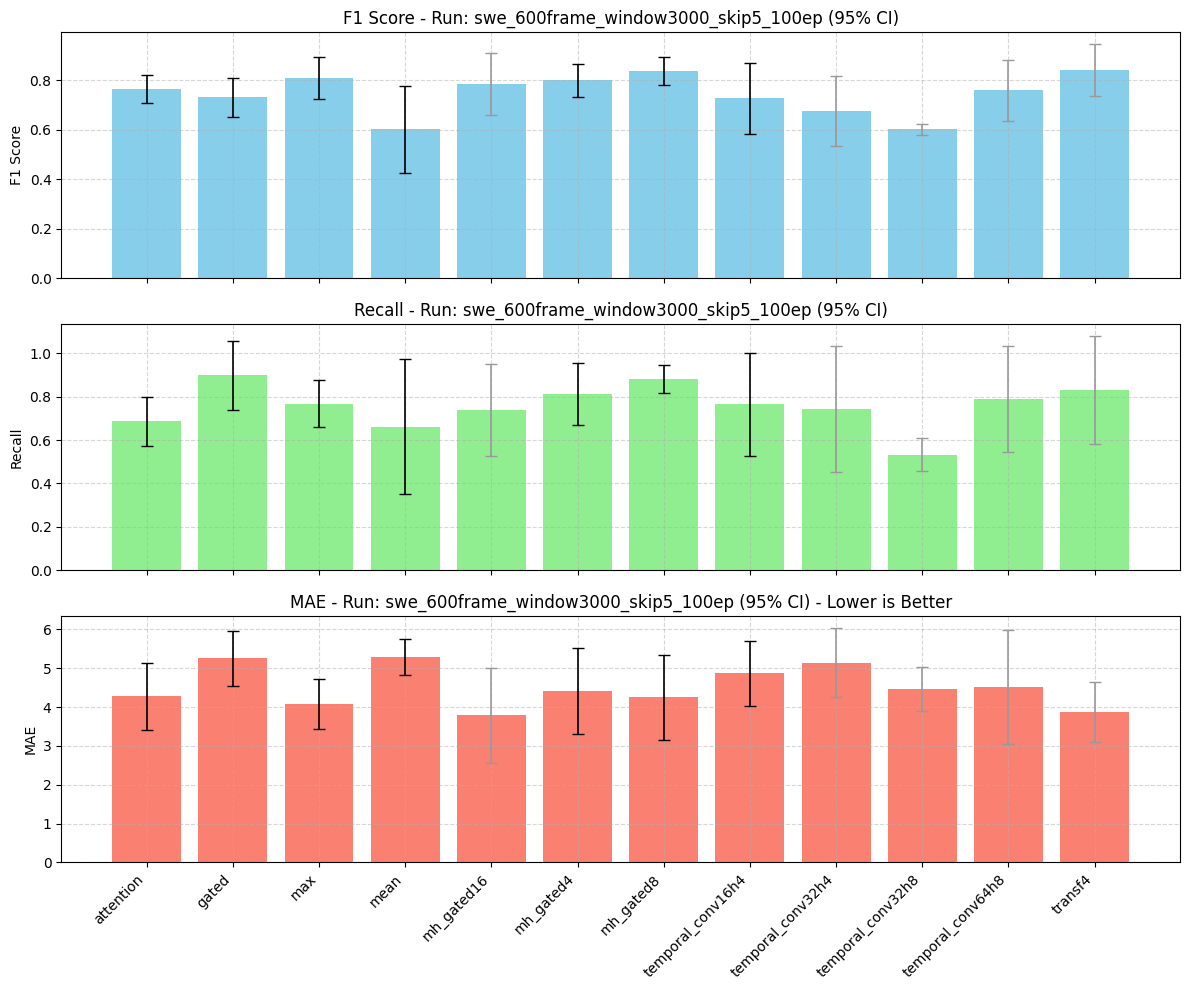

In [8]:
# Macro + 95% CI
plot_cv_metrics(
    "/research/projects/Sahika/projects/liver_PDFF/clean_code/runs/swin_tiny_patch4_window7_224.ms_in1k_gelu_CV/swe_600frame_window3000_skip5_100ep",
    thresh=5.0,
    use_macro=True,
    ci=True
)

In [10]:
results

NameError: name 'results' is not defined